grades: 60,000 filas | enrollments: 25,000 filas

=== Chequeo 1: suma(weight) == 1.0 por inscripcion ===
Inscripciones con al menos 1 nota: 22,786
  suma == 1 (tolerancia 0.01): 141 (0.6%)
  suma != 1:                         22,645 (99.4%)
count    22786.000000
mean         0.790914
std          0.466860
min          0.100000
25%          0.430000
50%          0.710000
75%          1.060000
max          3.310000
Name: suma_pesos, dtype: float64

=== Chequeo 2: la suma de pesos depende de CUANTAS notas hay, no de un rubro fijo ===
Correlacion (n_evaluaciones, suma_pesos): 0.915
Peso promedio por evaluacion, sin importar cuantas haya en la inscripcion:
count    22786.000000
mean         0.300115
std          0.082947
min          0.100000
25%          0.245000
50%          0.300000
75%          0.355000
max          0.500000
dtype: float64
>> Si weight fuera un rubro de verdad (ej. suma fija = 1), este ratio variaria segun n_evaluaciones. En cambio se mantiene ~0.30 siempre, lo que indi

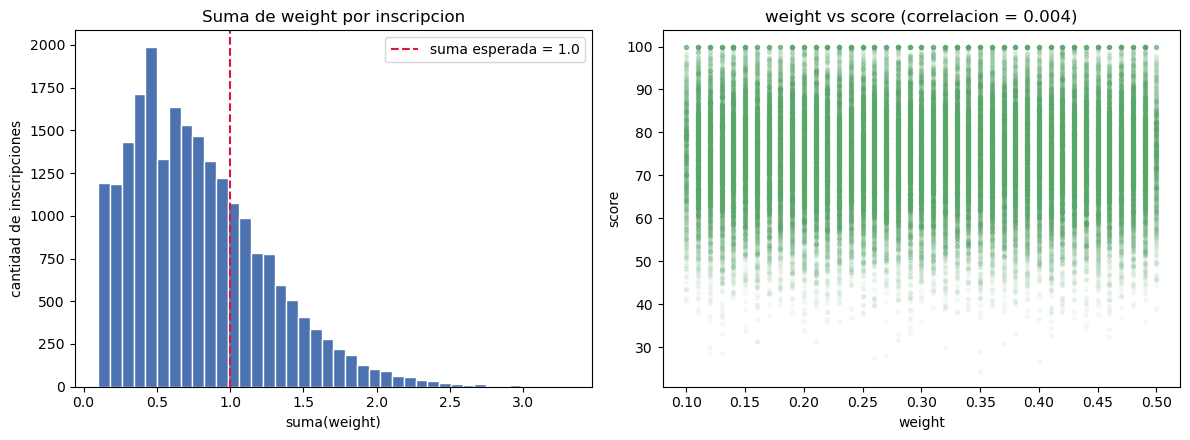

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

# ==========================================================
# 1. CARGA DE DATOS
# ==========================================================
GRADES_PATH = "/home/jovyan/work/data/raw/university/grades.csv"
ENROLLMENTS_PATH = "/home/jovyan/work/data/raw/university/enrollments.csv"

grades = pd.read_csv(GRADES_PATH)
enrollments = pd.read_csv(ENROLLMENTS_PATH)

print(f"grades: {len(grades):,} filas | enrollments: {len(enrollments):,} filas")

# ==========================================================
# 2. LA SUMA DE PESOS POR INSCRIPCION NO DA 1.0
# ==========================================================
por_inscripcion = (
    grades.groupby("enrollment_id")
    .agg(n_evaluaciones=("grade_id", "count"), suma_pesos=("weight", "sum"))
    .reset_index()
)

tolerancia = 0.01
suma_ok = (por_inscripcion["suma_pesos"] - 1).abs() <= tolerancia

print("\n=== Chequeo 1: suma(weight) == 1.0 por inscripcion ===")
print(f"Inscripciones con al menos 1 nota: {len(por_inscripcion):,}")
print(f"  suma == 1 (tolerancia {tolerancia}): {suma_ok.sum():,} "
      f"({suma_ok.mean():.1%})")
print(f"  suma != 1:                         {(~suma_ok).sum():,} "
      f"({(~suma_ok).mean():.1%})")
print(por_inscripcion["suma_pesos"].describe())

correlacion_n_suma = por_inscripcion[["n_evaluaciones", "suma_pesos"]].corr().iloc[0, 1]

print("\n=== Chequeo 2: la suma de pesos depende de CUANTAS notas hay, no de un rubro fijo ===")
print(f"Correlacion (n_evaluaciones, suma_pesos): {correlacion_n_suma:.3f}")
print("Peso promedio por evaluacion, sin importar cuantas haya en la inscripcion:")
print((por_inscripcion["suma_pesos"] / por_inscripcion["n_evaluaciones"]).describe())
print(">> Si weight fuera un rubro de verdad (ej. suma fija = 1), este ratio "
      "variaria segun n_evaluaciones. En cambio se mantiene ~0.30 siempre, "
      "lo que indica que cada fila trae un peso independiente y aleatorio.")

correlacion_weight_score = grades[["weight", "score"]].corr().iloc[0, 1]

print("\n=== Chequeo 3: weight vs score ===")
print(f"Correlacion (weight, score): {correlacion_weight_score:.3f}")
print(">> Practicamente cero: el peso de una evaluacion no se relaciona con "
      "el desempeno obtenido en ella.")

print("\n=== Chequeo 4: distribucion de weight por tipo de evaluacion ===")
print(grades.groupby("assessment")["weight"].describe()[["mean", "std", "min", "max"]])
print(">> Las 5 categorias (quiz, homework, midterm, project, final) tienen "
      "la misma media (~0.30) y el mismo rango (0.10-0.50): no hay una "
      "jerarquia de importancia por tipo, como esperariamos de un rubro real.")


total_inscripciones = len(enrollments)
con_notas = enrollments["enrollment_id"].isin(grades["enrollment_id"])
sin_notas = (~con_notas).sum()

print("\n=== Chequeo 5: inscripciones sin evaluaciones ===")
print(f"Total inscripciones: {total_inscripciones:,}")
print(f"Sin ninguna fila en grades: {sin_notas:,} ({sin_notas/total_inscripciones:.1%})")
print(">> La nota final de estas inscripciones debe quedar NULA, no cero.")

# ==========================================================
# 7. MISMO TIPO DE EVALUACION REPETIDO EN LA MISMA INSCRIPCION
# ==========================================================
repetidos = (
    grades.groupby(["enrollment_id", "assessment"]).size().reset_index(name="n")
)
pct_repetido = (repetidos["n"] > 1).mean()

print("\n=== Chequeo 6: mismo tipo de evaluacion repetido en una inscripcion ===")
print(f"Pares (inscripcion, tipo_evaluacion) con >1 registro: "
      f"{(repetidos['n'] > 1).sum():,} / {len(repetidos):,} ({pct_repetido:.1%})")

caso = repetidos[repetidos["n"] > 1].iloc[0]
ejemplo = grades[
    (grades["enrollment_id"] == caso["enrollment_id"])
    & (grades["assessment"] == caso["assessment"])
].sort_values("graded_at")
print("Ejemplo real (misma inscripcion, mismo tipo, fechas muy distantes):")
print(ejemplo[["assessment", "score", "weight", "graded_at"]])

# ==========================================================
# 8. VISUALIZACION DE APOYO
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(por_inscripcion["suma_pesos"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].axvline(1.0, color="crimson", linestyle="--", label="suma esperada = 1.0")
axes[0].set_title("Suma de weight por inscripcion")
axes[0].set_xlabel("suma(weight)")
axes[0].set_ylabel("cantidad de inscripciones")
axes[0].legend()

axes[1].scatter(grades["weight"], grades["score"], alpha=0.05, s=8, color="#55A868")
axes[1].set_title(f"weight vs score (correlacion = {correlacion_weight_score:.3f})")
axes[1].set_xlabel("weight")
axes[1].set_ylabel("score")

plt.tight_layout()
plt.savefig("evidencia_pesos_grades.png", dpi=150)
print("\nGrafico guardado en evidencia_pesos_grades.png")

# ==========================================================
# 9. RESUMEN
# ==========================================================
print("\n" + "=" * 70)
print("RESUMEN")
print("=" * 70)
print(f"- {(~suma_ok).mean():.0%} de las inscripciones NO tienen suma(weight) == 1")
print(f"- La suma correlaciona {correlacion_n_suma:.2f} con la cantidad de notas "
      "(no con un rubro fijo)")
print(f"- weight vs score correlaciona {correlacion_weight_score:.2f} (~ninguna relacion)")
print("- weight no varia por tipo de evaluacion (quiz ~= final ~= midterm)")
print(f"- {sin_notas:,} inscripciones ({sin_notas/total_inscripciones:.1%}) no tienen "
      "ninguna evaluacion registrada")
print(f"- {pct_repetido:.0%} de los pares (inscripcion, tipo) tienen el mismo tipo "
      "de evaluacion repetido")
print("\n>> Conclusion: weight no es recuperable como un rubro de evaluacion real.")
print(">> Decision propuesta: nota_final = promedio simple de score por inscripcion,")
print(">>   documentada en docs/decisiones.md con esta evidencia.")